# Crop margin: 0.10 vs 0.50 (5-fold CV, training set only)

**Question:** would a wider crop around the lesion help the image model? On the test set, several large melanomas
that filled the 10%-margin crop edge to edge got very low probabilities, while their uncropped versions didn't.
A 50% margin keeps more of the surrounding skin, so the lesion's border and its contrast with normal skin stay visible.

**Design: everything is identical except the crop margin**
- Same model and every hyperparameter as `final_model_resnet.ipynb`: frozen ResNet50, MLP head 128 → 32 → 1,
  dropout 0.4 / 0.6 / 0.4, L2 1e-3, Adam 5e-4, batch 32, 70/30 oversampling with augmentation, balanced class weights,
  up to 20 epochs with early stopping (patience 5) on fold val AUC.
- Same 5 patient-grouped folds of `training_set.csv`, with the same seed. Each fold uses the same patients and the
  same random seed at both margins, so only the images differ.
- Same crop pipeline (hair removal → marker/vignette cleaning → lesion box → margin → 224×224), same `NO_CROP_IDS`.
  0.10 is your current crop; 0.50 adds half the box's width/height on each side.
- `validation_set.csv` and the test set are **not used**.

The 0.10 run should reproduce `final_model_resnet.ipynb`'s out-of-fold ROC-AUC (~0.796): a check that the setup matches.

**Decision rule** (set before looking at the results): 0.50 counts as a real improvement only if it beats 0.10 in
**at least 4 of 5 folds** *and* the 95% patient-level bootstrap CI for the pooled ROC-AUC difference (0.50 − 0.10)
**stays above 0**. Otherwise keep 0.10. If 0.50 wins, the next step is retraining the final model in
`final_model_resnet.ipynb` with `CROP_MARGIN = 0.50`.

In [1]:
import os
import random

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf

# Fix every source of randomness up front so results are reproducible run-to-run --
# TensorFlow's own RNG (weight init) and GPU op-level determinism need pinning
# separately from numpy/sklearn: cuDNN picks nondeterministic algorithms by default.
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()

## (Colab only) Unpack data from Google Drive

Same as `final_model_resnet.ipynb`: mounts Drive and unzips `melanoma_data.zip` into `/content`. No-op locally.

In [2]:
import os

if os.path.isdir('/content'):
    os.chdir('/content')
    if not os.path.isdir('train'):
        DRIVE_ZIP_PATH = '/content/drive/MyDrive/melanoma_data.zip'  # adjust if you put it elsewhere in Drive

        from google.colab import drive
        drive.mount('/content/drive')

        zip_source = DRIVE_ZIP_PATH if os.path.exists(DRIVE_ZIP_PATH) else 'melanoma_data.zip'
        assert os.path.exists(zip_source), (
            f"Couldn't find the data zip at {DRIVE_ZIP_PATH} or /content/melanoma_data.zip -- "
            "upload melanoma_data.zip to your Google Drive (or directly to Colab) first"
        )
        get_ipython().system(f'unzip -q "{zip_source}"')
    print('data ready in', os.getcwd())

Mounted at /content/drive
data ready in /content


In [3]:
# VS Code's Jupyter extension can run this notebook with the *workspace root* as the
# working directory, which breaks every relative path below -- hop into this notebook's
# own folder if we're not already there (and not on Colab, which uses /content).
import os

_nb_path = globals().get('__vsc_ipynb_file__')
if _nb_path and not os.path.isdir('/content'):
    os.chdir(os.path.dirname(_nb_path))

print('working directory:', os.getcwd())

working directory: /content


## Labels and training set

In [4]:
import pandas as pd

TRAIN_DIR = 'train'

# sorted() so image order (and so every fold split) is identical across machines/runs
train_files = sorted(f for f in os.listdir(TRAIN_DIR) if f.lower().endswith('.jpg'))
files_df = pd.DataFrame({
    'image_name': [os.path.splitext(f)[0] for f in train_files],
    'image_path': [os.path.join(TRAIN_DIR, f) for f in train_files],
})
labels_df = pd.read_csv('train_labels.csv')
image_df = files_df.merge(labels_df, on='image_name', how='inner')[['image_name', 'patient_id', 'image_path', 'target']]

print(f'{len(image_df)} labelled images, {image_df["patient_id"].nunique()} patients, '
      f'{int(image_df["target"].sum())} malignant ({image_df["target"].mean():.2%})')

6864 labelled images, 422 patients, 128 malignant (1.86%)


In [5]:
import shutil

SPLIT_FILES = ['training_set.csv', 'validation_set.csv']
DRIVE_SPLIT_DIR = '/content/drive/MyDrive'  # adjust if you put them elsewhere in Drive

if os.path.isdir('/content'):
    for f in SPLIT_FILES:
        if not os.path.exists(f) and os.path.exists(os.path.join(DRIVE_SPLIT_DIR, f)):
            shutil.copy(os.path.join(DRIVE_SPLIT_DIR, f), f)
            print(f'copied {f} from Google Drive')
    still_missing = [f for f in SPLIT_FILES if not os.path.exists(f)]
    if still_missing:
        print(f'upload {still_missing} now (or drop copies into {DRIVE_SPLIT_DIR} and re-run this cell):')
        from google.colab import files
        files.upload()

copied training_set.csv from Google Drive
copied validation_set.csv from Google Drive


In [6]:
# Training set only -- validation_set.csv is just loaded to double-check there's no patient overlap
train_df = image_df.merge(pd.read_csv('training_set.csv'), on='image_name', how='inner').reset_index(drop=True)
val_patients = set(image_df.merge(pd.read_csv('validation_set.csv'), on='image_name')['patient_id'])

assert len(train_df) == len(pd.read_csv('training_set.csv')), 'some training_set.csv image_names not found'
assert not (set(train_df['patient_id']) & val_patients), 'patient leakage between training/validation!'

y = train_df['target'].to_numpy().astype(int)
groups = train_df['patient_id'].to_numpy()
print(f'training: {len(train_df)} images, {train_df["patient_id"].nunique()} patients, '
      f'benign={int((y == 0).sum())}, malignant={int(y.sum())}')

training: 5629 images, 337 patients, benign=5526, malignant=103


## Crops for each margin

For each margin, restores `train_cropped_margin_<m>/` from `melanoma_cropped_margin_<m>.zip` (local, then Drive). The 0.10 zip
is the one `final_model_resnet.ipynb` trains on. If a margin has no zip yet, it's generated here with **exactly** the crop code
from `Crop_margin_ablation.ipynb` (same cleaning, lesion finder and `NO_CROP_IDS`), run on the hair-removed images
(`melanoma_hairless.zip`), then zipped and copied to Drive.

**If you're not sure the 0.50 zip on Drive was made with the current crop code**, set `REGENERATE[0.50] = True` for one
run. Otherwise a stale zip would make the comparison unfair.

In [7]:
import zipfile

MARGINS = [0.10, 0.50]
REGENERATE = {0.10: False, 0.50: False}   # True = ignore any cached zip and re-crop that margin from scratch
IMG_SIZE = 224
DRIVE_DIR = '/content/drive/MyDrive'

HAIRLESS_DIR = 'train_hairless'
HAIRLESS_ZIP = 'melanoma_hairless.zip'

NO_CROP_IDS = {
    'ISIC_1008321', 'ISIC_1259091', 'ISIC_1366993', 'ISIC_1620401', 'ISIC_1646954', 'ISIC_2806424',
    'ISIC_2902504', 'ISIC_3170416', 'ISIC_3420087', 'ISIC_3645670', 'ISIC_3782874', 'ISIC_3871153',
    'ISIC_4137198', 'ISIC_4944556', 'ISIC_4961493', 'ISIC_5038943', 'ISIC_5105824', 'ISIC_5298608',
    'ISIC_5303069', 'ISIC_5873438', 'ISIC_6089318', 'ISIC_6370792', 'ISIC_6501973', 'ISIC_6712470',
    'ISIC_6767569', 'ISIC_6808583', 'ISIC_6966105', 'ISIC_7177998', 'ISIC_7204247', 'ISIC_7382357',
    'ISIC_7461756', 'ISIC_7465944', 'ISIC_7492471', 'ISIC_7594368', 'ISIC_7681593', 'ISIC_7690107',
    'ISIC_8249427', 'ISIC_8338138', 'ISIC_8847503', 'ISIC_9135299', 'ISIC_9581761', 'ISIC_9644412',
}


def margin_dir(margin):
    return f'train_cropped_margin_{margin:.2f}'


def margin_zip(margin):
    return f'melanoma_cropped_margin_{margin:.2f}.zip'


def unzip(path, dest):
    os.makedirs(dest, exist_ok=True)
    with zipfile.ZipFile(path) as zf:
        zf.extractall(dest)


if os.path.isdir('/content') and not os.path.isdir('/content/drive'):
    from google.colab import drive
    drive.mount('/content/drive')

needs_cropping = []
for margin in MARGINS:
    out_dir = margin_dir(margin)
    if REGENERATE[margin]:
        shutil.rmtree(out_dir, ignore_errors=True)
    if os.path.isdir(out_dir) and os.listdir(out_dir):
        print(f'margin={margin:.2f}: {len(os.listdir(out_dir))} crops already in {out_dir}/')
        continue
    cached = None if REGENERATE[margin] else next(
        (z for z in (margin_zip(margin), os.path.join(DRIVE_DIR, margin_zip(margin))) if os.path.exists(z)), None)
    if cached:
        unzip(cached, out_dir)
        print(f'margin={margin:.2f}: restored {len(os.listdir(out_dir))} crops from {cached}')
    else:
        needs_cropping.append(margin)
print('margins to generate:', needs_cropping or 'none')

margin=0.10: restored 6864 crops from /content/drive/MyDrive/melanoma_cropped_margin_0.10.zip
margin=0.50: restored 6864 crops from /content/drive/MyDrive/melanoma_cropped_margin_0.50.zip
margins to generate: none


### Generate missing crops (skipped when every margin was restored)

Copied from `Crop_margin_ablation.ipynb` (hair removal, cleaning, lesion finder, `crop_with_margin`). Needs
`boundary_localization.py` (fetched from Drive on Colab). Takes a while for ~6,900 images, but only runs once per margin.

In [8]:
if needs_cropping:
    import shutil

    # boundary_localization.py must sit next to this notebook (in /content on Colab) to be importable.
    # On Colab, copy it in from Google Drive -- MyDrive/ itself, or anywhere else in Drive (searched if needed).
    if os.path.isdir('/content') and not os.path.exists('boundary_localization.py'):
        if not os.path.isdir('/content/drive'):
            from google.colab import drive
            drive.mount('/content/drive')
        candidates = ['/content/drive/MyDrive/boundary_localization.py']
        if not os.path.exists(candidates[0]):
            import glob
            candidates = glob.glob('/content/drive/MyDrive/**/boundary_localization.py', recursive=True)
        assert candidates and os.path.exists(candidates[0]), 'boundary_localization.py not found anywhere in MyDrive'
        shutil.copy(candidates[0], 'boundary_localization.py')
        print(f'copied {candidates[0]} -> {os.getcwd()}/boundary_localization.py')

    import cv2


    def remove_hair(img_rgb, kernel_size=9, inpaint_radius=6, thresh=10):
        gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
        kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (kernel_size, kernel_size))
        blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
        blurred = cv2.GaussianBlur(blackhat, (3, 3), cv2.BORDER_DEFAULT)
        _, hair_mask = cv2.threshold(blurred, thresh, 255, cv2.THRESH_BINARY)
        return cv2.inpaint(img_rgb, hair_mask, inpaint_radius, cv2.INPAINT_TELEA)

    import boundary_localization
    from boundary_localization import boundary_localization_crop, remove_marker, remove_dark_marker, strip_rectangular_artifacts


    def remove_border_vignette(img_rgb, dark_thresh=60, inpaint_radius=6, morph_kernel_size=31, sat_thresh=50):
        """Same as boundary_localization.remove_border_vignette, plus a saturation check:
        a pixel only counts as vignette if it is dark AND nearly colourless (HSV S <
        sat_thresh). A real vignette is near-black/grey, while a dark melanoma is still
        strongly red-brown (e.g. ISIC dark-lesion pixels measured S ~127-255), so a large
        dark lesion running off the image edge no longer gets flagged and flat-filled."""
        gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
        sat = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)[..., 1]
        dark_mask = ((gray < dark_thresh) & (sat < sat_thresh)).astype(np.uint8)

        if morph_kernel_size > 0:
            kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (morph_kernel_size, morph_kernel_size))
            dark_mask = cv2.morphologyEx(dark_mask, cv2.MORPH_CLOSE, kernel)

        _, labels = cv2.connectedComponents(dark_mask)
        border_labels = set(labels[0, :]) | set(labels[-1, :]) | set(labels[:, 0]) | set(labels[:, -1])
        border_labels.discard(0)
        if not border_labels:
            return img_rgb, np.zeros_like(dark_mask, dtype=np.uint8)

        vignette_mask = np.isin(labels, list(border_labels)).astype(np.uint8) * 255
        non_vignette = vignette_mask == 0
        if not non_vignette.any():
            return cv2.inpaint(img_rgb, vignette_mask, inpaint_radius, cv2.INPAINT_TELEA), vignette_mask

        cleaned = img_rgb.copy()
        cleaned[vignette_mask == 255] = img_rgb[non_vignette].reshape(-1, 3).mean(axis=0)
        return cleaned, vignette_mask


    # boundary_localization_crop looks remove_border_vignette up in its own module, so
    # swap the patched version in there too -- otherwise the bounding box would still
    # be found on the flat-filled image.
    boundary_localization.remove_border_vignette = remove_border_vignette


    def clean_image(image):
        """Reapplies the same marker/vignette/rectangular-artifact removal steps
        boundary_localization_crop runs internally (its own defaults) before
        segmenting. Needed here because that function only returns the crop AT its
        own (0-margin) bounding box, not the full cleaned image -- to expand the box
        ourselves we need the full cleaned image to slice from, not the raw one."""
        cleaned, _ = remove_marker(image)
        cleaned, _ = remove_dark_marker(cleaned)
        cleaned = strip_rectangular_artifacts(cleaned)
        cleaned, _ = remove_border_vignette(cleaned)
        return cleaned


    GRAY_MIN_CONTRAST = 15   # grayscale pick is trusted at/above this lesion-vs-surroundings gap
    SAT_MIN_CONTRAST = 30    # saturation fallback is trusted at/above this gap
    AGREE_IOU = 0.5          # gray and saturation boxes this similar -> trust gray even at low contrast
    MARKER_HUES = (95, 155)  # OpenCV hue range of blue/purple pen marker, excluded from the saturation map


    def _region_contrast(chan, mask, bbox_local):
        """Mean of `chan` in a ring just outside the chosen contour minus the mean inside it --
        how much the picked region actually stands out from the skin around it."""
        x, y, w, h = bbox_local
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        contours = [c for c in contours if cv2.boundingRect(c) == (x, y, w, h)]
        if not contours:
            return 0.0
        inside = np.zeros(chan.shape, np.uint8)
        cv2.drawContours(inside, contours, -1, 255, cv2.FILLED)
        r = max(5, int(0.15 * max(w, h)))
        ring = cv2.dilate(inside, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * r + 1, 2 * r + 1)))
        ring = (ring > 0) & (inside == 0)
        if not ring.any():
            return 0.0
        return float(chan[ring].mean() - chan[inside > 0].mean())


    def _iou(a, b):
        ax, ay, aw, ah = a
        bx, by, bw, bh = b
        iw = max(0, min(ax + aw, bx + bw) - max(ax, bx))
        ih = max(0, min(ay + ah, by + bh) - max(ay, by))
        inter = iw * ih
        return inter / (aw * ah + bw * bh - inter)


    def locate_lesion(image, cleaned):
        """Returns (bbox, method) -- bbox is None when neither channel finds a convincing lesion.

        1. gray: the existing boundary_localization_crop (Otsu on darkness). Kept if the picked
           region is clearly darker than its surroundings, or if the saturation box agrees with it.
        2. saturation: light/low-contrast lesions often barely differ from skin in brightness
           (lens fall-off can make the image edges darker than the lesion), but are still much
           more coloured than the surrounding skin. Runs the same Otsu + plausibility filters on
           255 - S so the most saturated region becomes the "dark" foreground.
        3. none: fall back to the whole cleaned image rather than crop to a wrong region."""
        _, gray_bbox, gray_mask = boundary_localization_crop(image, output_size=None)
        gray = cv2.cvtColor(cleaned, cv2.COLOR_RGB2GRAY)
        # gray_mask is in border-stripped coordinates -- recover that offset from the matching contour
        contours, _ = cv2.findContours(gray_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        local = [cv2.boundingRect(c) for c in contours if cv2.boundingRect(c)[2:] == gray_bbox[2:]]
        gray_contrast = 0.0
        if local:
            ox, oy = gray_bbox[0] - local[0][0], gray_bbox[1] - local[0][1]
            mh, mw = gray_mask.shape
            gray_contrast = _region_contrast(gray[oy:oy + mh, ox:ox + mw].astype(np.float64), gray_mask, local[0])
        if gray_contrast >= GRAY_MIN_CONTRAST:
            return gray_bbox, 'gray'

        hsv = cv2.cvtColor(cleaned, cv2.COLOR_RGB2HSV)
        sat = hsv[..., 1].copy()
        sat[(hsv[..., 0] >= MARKER_HUES[0]) & (hsv[..., 0] <= MARKER_HUES[1])] = 0
        inv_sat = 255 - sat
        _, sat_bbox, sat_mask = boundary_localization_crop(
            np.repeat(inv_sat[..., None], 3, axis=2), output_size=None,
            strip_marker=False, strip_dark_marker=False, strip_rectangular=False,
            strip_border_vignette=False, strip_uniform_border=False)  # already cleaned; keep coords unshifted
        if _iou(gray_bbox, sat_bbox) >= AGREE_IOU:
            return gray_bbox, 'gray'
        if _region_contrast(inv_sat.astype(np.float64), sat_mask, sat_bbox) >= SAT_MIN_CONTRAST:
            return sat_bbox, 'saturation'
        return None, 'none'


    def crop_with_margin(image, margin, output_size=IMG_SIZE):
        img_h, img_w = image.shape[:2]
        cleaned = clean_image(image)
        bbox, _ = locate_lesion(image, cleaned)
        if bbox is None:
            return cv2.resize(cleaned, (output_size, output_size), interpolation=cv2.INTER_AREA)
        x, y, w, h = bbox

        mx, my = margin * w, margin * h
        x0 = max(0, int(round(x - mx)))
        y0 = max(0, int(round(y - my)))
        x1 = min(img_w, int(round(x + w + mx)))
        y1 = min(img_h, int(round(y + h + my)))
        crop = cleaned[y0:y1, x0:x1]

        return cv2.resize(crop, (output_size, output_size), interpolation=cv2.INTER_AREA)


    # Hair-removed full images: restore the cached zip, else run DullRazor on train/
    if not os.path.isdir(HAIRLESS_DIR) or not os.listdir(HAIRLESS_DIR):
        cached = next((z for z in (HAIRLESS_ZIP, os.path.join(DRIVE_DIR, HAIRLESS_ZIP)) if os.path.exists(z)), None)
        if cached:
            unzip(cached, HAIRLESS_DIR)
            print(f'restored hair-removed images from {cached}')
        else:
            os.makedirs(HAIRLESS_DIR, exist_ok=True)
            for i, path in enumerate(image_df['image_path']):
                with Image.open(path) as img:
                    Image.fromarray(remove_hair(np.array(img.convert('RGB')))).save(
                        os.path.join(HAIRLESS_DIR, os.path.basename(path)), quality=95)
                if (i + 1) % 1000 == 0:
                    print(f'hair removal: {i + 1}/{len(image_df)}')

    hairless_files = sorted(f for f in os.listdir(HAIRLESS_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png')))
    for margin in needs_cropping:
        out_dir = margin_dir(margin)
        os.makedirs(out_dir, exist_ok=True)
        for i, fname in enumerate(hairless_files):
            with Image.open(os.path.join(HAIRLESS_DIR, fname)) as img:
                arr = np.array(img.convert('RGB'))
            if os.path.splitext(fname)[0] in NO_CROP_IDS:
                out = cv2.resize(arr, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
            else:
                out = crop_with_margin(arr, margin)
            Image.fromarray(out).save(os.path.join(out_dir, fname))
            if (i + 1) % 1000 == 0:
                print(f'margin={margin:.2f}: {i + 1}/{len(hairless_files)} cropped')
        with zipfile.ZipFile(margin_zip(margin), 'w', zipfile.ZIP_DEFLATED) as zf:
            for fname in sorted(os.listdir(out_dir)):
                zf.write(os.path.join(out_dir, fname), arcname=fname)
        if os.path.isdir(DRIVE_DIR):
            shutil.copy(margin_zip(margin), os.path.join(DRIVE_DIR, margin_zip(margin)))
        print(f'margin={margin:.2f}: generated {len(os.listdir(out_dir))} crops, cached to {margin_zip(margin)}')

# Every training image needs a crop at every margin
for margin in MARGINS:
    crops = {f for f in os.listdir(margin_dir(margin)) if f.lower().endswith(('.jpg', '.jpeg', '.png'))}
    missing = sorted({os.path.basename(p) for p in train_df['image_path']} - crops)
    assert not missing, f'margin={margin:.2f}: {len(missing)} training images have no crop, e.g. {missing[:5]}'
print('every training image has a crop at every margin')

every training image has a crop at every margin


In [9]:
def load_images(paths, image_dir, img_size=IMG_SIZE):
    """Loads the same-filename image from image_dir for every path, as uint8 RGB."""
    X = np.empty((len(paths), img_size, img_size, 3), dtype=np.uint8)
    for i, path in enumerate(paths):
        with Image.open(os.path.join(image_dir, os.path.basename(path))) as img:
            X[i] = np.array(img.convert('RGB').resize((img_size, img_size)))
    return X

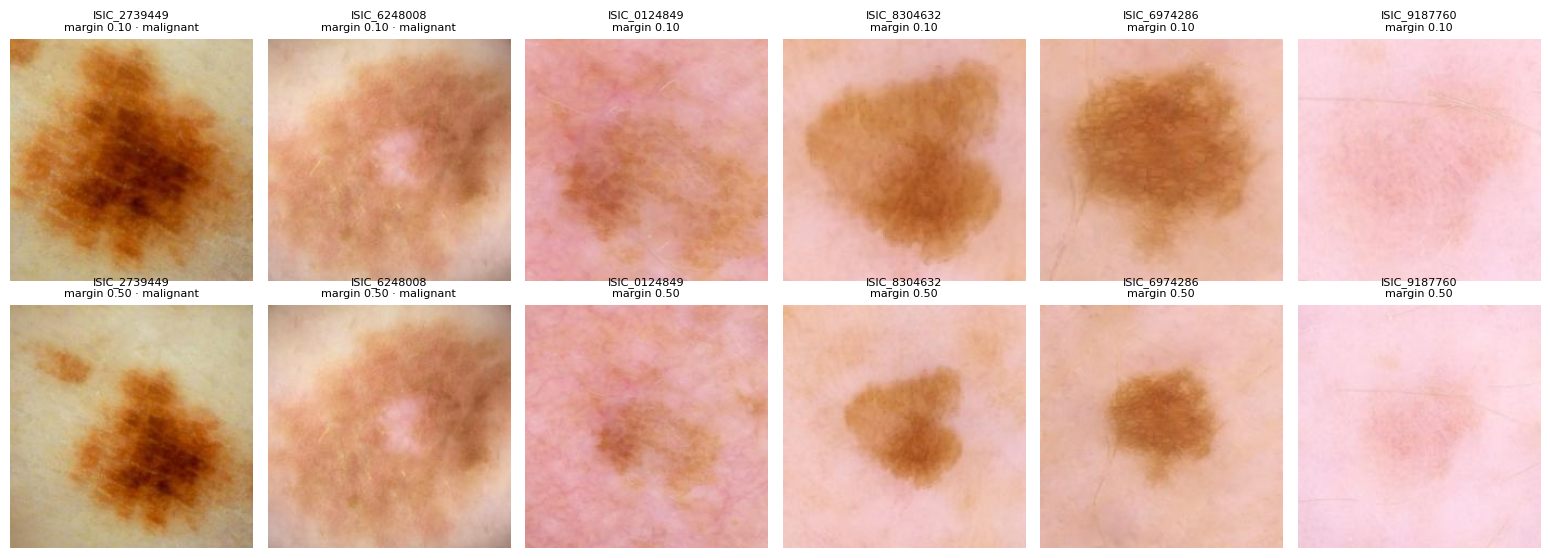

In [10]:
# Visual check: the same images at both margins (two malignant, four random benign)
rng = np.random.default_rng(0)
sample = pd.concat([train_df[train_df['target'] == 1].sample(2, random_state=0),
                    train_df[train_df['target'] == 0].sample(4, random_state=0)])
fig, axes = plt.subplots(len(MARGINS), len(sample), figsize=(2.6 * len(sample), 2.8 * len(MARGINS)), squeeze=False)
for r, margin in enumerate(MARGINS):
    imgs = load_images(sample['image_path'], margin_dir(margin))
    for c, (img, (_, row)) in enumerate(zip(imgs, sample.iterrows())):
        axes[r, c].imshow(img)
        axes[r, c].set_title(f"{row['image_name']}\nmargin {margin:.2f}" + (' · malignant' if row['target'] else ''), fontsize=8)
        axes[r, c].axis('off')
plt.tight_layout()
plt.show()

## Augmentation and model (copied from `final_model_resnet.ipynb`)

In [11]:
import albumentations as A
import cv2

melanoma_augment = A.Compose([
    A.Transpose(p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.75),
    A.OneOf([
        A.MotionBlur(blur_limit=3),
        A.MedianBlur(blur_limit=3),
        A.GaussianBlur(blur_limit=3),
        A.GaussNoise(std_range=(0.02, 0.08)),
    ], p=0.7),
    A.CLAHE(clip_limit=4.0, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0, rotate_limit=15,
                        border_mode=cv2.BORDER_REFLECT_101, p=0.85),
    A.CoarseDropout(num_holes_range=(1, 1),
                     hole_height_range=(0.1, 0.2), hole_width_range=(0.1, 0.2),
                     p=0.5),
])

/usr/local/lib/python3.13/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [12]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess_input
from sklearn.utils.class_weight import compute_class_weight

# Best settings from the ResNet50 + MLP grid search in Basic_CNN_model.ipynb
MLP_HIDDEN_UNITS = [128, 32]
INPUT_DROPOUT_RATE = 0.4          # 'high' dropout preset -- on the frozen ResNet50 features
MLP_DROPOUT_RATES = [0.6, 0.4]    # 'high' dropout preset -- after each hidden layer
L2_STRENGTH = 1e-3
LEARNING_RATE = 5e-4
BATCH_SIZE = 32
TARGET_MINORITY_RATIO = 0.3       # oversample malignant to a 70/30 benign/malignant mix
CLASS_WEIGHT_BLEND = 1.0          # 1.0 = fully 'balanced' class weights
MAX_EPOCHS = 20
PATIENCE = 5


def make_resnet_dataset(images, labels=None, batch_size=BATCH_SIZE):
    """Streams uint8 images through ResNet50's preprocess_input in batches (converting the whole
    array to float32 up front would need several GB)."""
    if labels is None:
        ds = tf.data.Dataset.from_tensor_slices(images)
        prep = lambda x: resnet_preprocess_input(tf.cast(x, tf.float32))
    else:
        ds = tf.data.Dataset.from_tensor_slices((images, labels))
        prep = lambda x, lbl: (resnet_preprocess_input(tf.cast(x, tf.float32)), lbl)
    return ds.map(prep, num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size).prefetch(tf.data.AUTOTUNE)


def augment_and_preprocess(image, label):
    def _augment(img):
        return melanoma_augment(image=img.numpy())['image']
    augmented = tf.py_function(_augment, [image], tf.uint8)
    augmented.set_shape(image.shape)
    return resnet_preprocess_input(tf.cast(augmented, tf.float32)), label


def n_oversampled(labels, ratio=TARGET_MINORITY_RATIO):
    """(n_benign, n_malignant after oversampling) for a training set."""
    n_benign, n_mal = int((labels == 0).sum()), int((labels == 1).sum())
    return n_benign, max(n_mal, int(round(n_benign * ratio / (1 - ratio))))


def make_training_dataset(images, labels, seed, ratio=TARGET_MINORITY_RATIO, batch_size=BATCH_SIZE):
    """Originals (un-augmented) + malignant images oversampled by index to `ratio`; each oversampled
    copy gets a fresh random melanoma_augment transform every epoch."""
    rng = np.random.default_rng(seed)
    minority_idx = np.where(labels == 1)[0]
    _, n_target = n_oversampled(labels, ratio)
    extra_idx = rng.choice(minority_idx, size=n_target - len(minority_idx), replace=True)

    base_ds = tf.data.Dataset.from_tensor_slices((images, labels)).map(
        lambda img, lbl: (resnet_preprocess_input(tf.cast(img, tf.float32)), lbl),
        num_parallel_calls=tf.data.AUTOTUNE)
    extra_ds = tf.data.Dataset.from_tensor_slices((images[extra_idx], labels[extra_idx])).map(
        augment_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = base_ds.concatenate(extra_ds).shuffle(len(images) + len(extra_idx), seed=seed,
                                               reshuffle_each_iteration=True)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


def blended_class_weight(labels, ratio=TARGET_MINORITY_RATIO, blend=CLASS_WEIGHT_BLEND):
    """'balanced' class weights computed at the post-oversampling mix, blended toward 1.0."""
    n_benign, n_mal = n_oversampled(labels, ratio)
    mix = np.concatenate([np.zeros(n_benign, dtype=int), np.ones(n_mal, dtype=int)])
    weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=mix)
    return {k: 1.0 + blend * (w - 1.0) for k, w in enumerate(weights)}


def build_resnet_mlp():
    base = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3), pooling='avg')
    base.trainable = False  # frozen backbone -- only the MLP head trains

    reg = lambda: tf.keras.regularizers.l2(L2_STRENGTH)
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.Dropout(INPUT_DROPOUT_RATE)(x)
    for units, rate in zip(MLP_HIDDEN_UNITS, MLP_DROPOUT_RATES):
        x = layers.Dense(units, activation='relu', kernel_regularizer=reg())(x)
        x = layers.Dropout(rate)(x)
    outputs = layers.Dense(1, activation='sigmoid', kernel_regularizer=reg())(x)
    model = models.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')],
    )
    return model


def plot_training_history(history, title, metrics=('loss', 'auc', 'precision', 'recall')):
    fig, axes = plt.subplots(1, len(metrics), figsize=(4.5 * len(metrics), 3.6))
    for ax, metric in zip(axes, metrics):
        ax.plot(history.history[metric], label='train')
        if f'val_{metric}' in history.history:
            ax.plot(history.history[f'val_{metric}'], label='val')
        ax.set_title(metric)
        ax.set_xlabel('epoch')
        ax.legend()
        ax.grid(alpha=0.3)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

## Folds

Same `StratifiedGroupKFold` call, seed and training-set order as `final_model_resnet.ipynb`, so these are the same 5 folds.

In [13]:
from sklearn.model_selection import StratifiedGroupKFold

N_FOLDS = 5
splitter = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

folds = []
for fold, (train_idx, val_idx) in enumerate(splitter.split(train_df, y, groups=groups), start=1):
    assert not (set(groups[train_idx]) & set(groups[val_idx])), f'fold {fold}: patient leakage'
    folds.append({'fold': fold, 'train': train_idx, 'val': val_idx})
    print(f'fold {fold}: train {len(train_idx)} ({y[train_idx].sum()} mal) | val {len(val_idx)} ({y[val_idx].sum()} mal)')

all_val = np.concatenate([f['val'] for f in folds])
assert len(all_val) == len(y) and len(set(all_val)) == len(y), 'val folds must cover every training image once'

fold 1: train 4441 (84 mal) | val 1188 (19 mal)
fold 2: train 4403 (81 mal) | val 1226 (22 mal)
fold 3: train 4621 (84 mal) | val 1008 (19 mal)
fold 4: train 4573 (77 mal) | val 1056 (26 mal)
fold 5: train 4478 (86 mal) | val 1151 (17 mal)


## 5-fold CV at each margin

For each margin and fold: a fresh model trains on that fold's 4/5 of patients, early-stops on the 5th, then predicts it.
The fold seed (`SEED + fold`) is the same at both margins. Results are saved after every fold to
`margin_cv_oof_<m>.csv` / `margin_cv_folds_<m>.csv` (copied to Drive), so if the runtime disconnects, re-running skips
finished folds. Delete those CSVs to start over.

Only one margin's images are in memory at a time (~850 MB each).

In [14]:
from sklearn.metrics import roc_auc_score, average_precision_score


def load_csv(name):
    path = next((p for p in (name, os.path.join(DRIVE_DIR, name)) if os.path.exists(p)), None)
    return pd.read_csv(path) if path else None


def save_csv(df, name):
    df.to_csv(name, index=False)
    if os.path.isdir(DRIVE_DIR):
        shutil.copy(name, os.path.join(DRIVE_DIR, name))


oof_name = lambda m: f'margin_cv_oof_{m:.2f}.csv'
fold_name = lambda m: f'margin_cv_folds_{m:.2f}.csv'

for margin in MARGINS:
    oof_df = load_csv(oof_name(margin))
    fold_summary = load_csv(fold_name(margin))
    oof_df = oof_df if oof_df is not None else pd.DataFrame()
    fold_summary = fold_summary if fold_summary is not None else pd.DataFrame()
    done = set(fold_summary['fold']) if len(fold_summary) else set()
    todo = [f for f in folds if f['fold'] not in done]
    print(f'===== margin {margin:.2f}: folds done {sorted(done) or "none"} =====')
    if not todo:
        continue

    X = load_images(train_df['image_path'], margin_dir(margin))
    for f in todo:
        tf.keras.backend.clear_session()
        tf.keras.utils.set_random_seed(SEED + f['fold'])
        model = build_resnet_mlp()

        train_ds = make_training_dataset(X[f['train']], y[f['train']], seed=SEED + f['fold'])
        val_ds = make_resnet_dataset(X[f['val']], labels=y[f['val']])
        early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=PATIENCE,
                                                      restore_best_weights=True)
        history = model.fit(train_ds, validation_data=val_ds, epochs=MAX_EPOCHS,
                            class_weight=blended_class_weight(y[f['train']]), callbacks=[early_stop], verbose=2)
        # restore_best_weights only kicks in when training actually stops early -- always use the best epoch
        if early_stop.best_weights is not None:
            model.set_weights(early_stop.best_weights)
        best_epoch = int(np.argmax(history.history['val_auc'])) + 1

        val_prob = model.predict(make_resnet_dataset(X[f['val']]), verbose=0).ravel()
        oof_df = pd.concat([oof_df, pd.DataFrame({
            'image_name': train_df['image_name'].to_numpy()[f['val']],
            'patient_id': groups[f['val']],
            'target': y[f['val']],
            'fold': f['fold'],
            'probability': val_prob,
        })], ignore_index=True)
        fold_summary = pd.concat([fold_summary, pd.DataFrame([{
            'fold': f['fold'],
            'best_epoch': best_epoch,
            'epochs_run': len(history.history['val_auc']),
            'val_auc': roc_auc_score(y[f['val']], val_prob),
            'val_pr_auc': average_precision_score(y[f['val']], val_prob),
            'n_val': len(f['val']),
            'n_val_malignant': int(y[f['val']].sum()),
        }])], ignore_index=True)
        save_csv(oof_df, oof_name(margin))
        save_csv(fold_summary, fold_name(margin))
        print(f"margin {margin:.2f}, fold {f['fold']}: best epoch {best_epoch}, val AUC {fold_summary['val_auc'].iloc[-1]:.4f}\n")
    del X

===== margin 0.10: folds done none =====
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Epoch 1/20
195/195 - 42s - 216ms/step - accuracy: 0.8046 - auc: 0.8824 - loss: 0.6989 - precision: 0.6455 - recall: 0.7734 - val_accuracy: 0.8855 - val_auc: 0.7969 - val_loss: 0.5320 - val_precision: 0.0667 - val_recall: 0.4737
Epoch 2/20
195/195 - 28s - 142ms/step - accuracy: 0.8819 - auc: 0.9429 - loss: 0.5241 - precision: 0.7783 - recall: 0.8479 - val_accuracy: 0.9579 - val_auc: 0.8319 - val_loss: 0.3972 - val_precision: 0.0571 - val_recall: 0.1053
Epoch 3/20
195/195 - 28s - 143ms/step - accuracy: 0.8994 - auc: 0.9523 - loss: 0.4696 - precision: 0.8101 - recall: 0.8682 - val_accuracy: 0.9436 - val_auc: 0.8324 - val_loss: 0.3811 - val_precision: 0.0862 - val_recall: 0.2632
Epoch 4/20
195/195 - 28s - 142ms/step - accuracy: 0.9089 - auc: 0.9586 - loss: 0.4261 - precision: 0.8344 - recall: 0.8688 - val_accuracy: 0.9419 - val_auc: 0.8279 - val_loss: 0.3686 - val_precision: 0.0968 - val_recall: 0.3

## Comparison: 0.10 vs 0.50

- **Pooled out-of-fold ROC-AUC / PR-AUC** for each margin (all ~100 training melanomas).
- **Per-fold scores**: same folds at both margins, so each fold is a paired comparison. How many folds does 0.50 win?
- **Patient-level paired bootstrap** of the pooled difference (0.50 − 0.10): resample *patients* with replacement
  (their images are correlated) 2,000 times, scoring both margins on the same resample each time.
- **Reproduction check**: 0.10 against `final_model_resnet.ipynb`'s saved out-of-fold predictions, if available.

Then the decision rule from the top of the notebook.

In [15]:
N_BOOT = 2000

oof = {m: load_csv(oof_name(m)) for m in MARGINS}
folds_res = {m: load_csv(fold_name(m)) for m in MARGINS}
assert all(df is not None and sorted(df['fold'].unique()) == list(range(1, N_FOLDS + 1)) for df in oof.values()), \
    'run every fold at every margin first'

m_lo, m_hi = MARGINS
paired = (oof[m_lo][['image_name', 'patient_id', 'target', 'fold', 'probability']]
          .merge(oof[m_hi][['image_name', 'fold', 'probability']], on='image_name', suffixes=('_lo', '_hi')))
assert len(paired) == len(train_df) and (paired['fold_lo'] == paired['fold_hi']).all(), 'folds differ between margins'
yt = paired['target'].to_numpy()
p_lo, p_hi = paired['probability_lo'].to_numpy(), paired['probability_hi'].to_numpy()

# Pooled + per-fold scores
summary = pd.DataFrame({
    f'margin {m:.2f}': {'pooled ROC-AUC': roc_auc_score(yt, p), 'pooled PR-AUC': average_precision_score(yt, p),
                        'median best epoch': folds_res[m]['best_epoch'].median()}
    for m, p in [(m_lo, p_lo), (m_hi, p_hi)]
}).T
display(summary.round(4))

per_fold = pd.DataFrame([{
    'fold': k,
    f'ROC-AUC {m_lo:.2f}': roc_auc_score(g['target'], g['probability_lo']),
    f'ROC-AUC {m_hi:.2f}': roc_auc_score(g['target'], g['probability_hi']),
    f'PR-AUC {m_lo:.2f}': average_precision_score(g['target'], g['probability_lo']),
    f'PR-AUC {m_hi:.2f}': average_precision_score(g['target'], g['probability_hi']),
    'n malignant': int(g['target'].sum()),
} for k, g in paired.groupby('fold_lo')])
per_fold['ROC-AUC diff'] = per_fold[f'ROC-AUC {m_hi:.2f}'] - per_fold[f'ROC-AUC {m_lo:.2f}']
per_fold['PR-AUC diff'] = per_fold[f'PR-AUC {m_hi:.2f}'] - per_fold[f'PR-AUC {m_lo:.2f}']
display(per_fold.round(4))
roc_wins = int((per_fold['ROC-AUC diff'] > 0).sum())
pr_wins = int((per_fold['PR-AUC diff'] > 0).sum())
print(f'margin {m_hi:.2f} beats {m_lo:.2f} in {roc_wins}/{N_FOLDS} folds on ROC-AUC, {pr_wins}/{N_FOLDS} on PR-AUC')

# Patient-level paired bootstrap of the pooled difference
patient_rows = paired.groupby('patient_id').indices
patient_ids = np.array(list(patient_rows))
boot_rng = np.random.default_rng(SEED)
diffs = {'ROC-AUC': [], 'PR-AUC': []}
for _ in range(N_BOOT):
    idx = np.concatenate([patient_rows[p] for p in boot_rng.choice(patient_ids, size=len(patient_ids), replace=True)])
    if yt[idx].min() == yt[idx].max():
        continue   # a resample with only one class can't be scored
    diffs['ROC-AUC'].append(roc_auc_score(yt[idx], p_hi[idx]) - roc_auc_score(yt[idx], p_lo[idx]))
    diffs['PR-AUC'].append(average_precision_score(yt[idx], p_hi[idx]) - average_precision_score(yt[idx], p_lo[idx]))
diffs = {k: np.array(v) for k, v in diffs.items()}

observed = {'ROC-AUC': roc_auc_score(yt, p_hi) - roc_auc_score(yt, p_lo),
            'PR-AUC': average_precision_score(yt, p_hi) - average_precision_score(yt, p_lo)}
ci = {k: np.percentile(v, [2.5, 97.5]) for k, v in diffs.items()}
for k in diffs:
    print(f'pooled {k} difference ({m_hi:.2f} - {m_lo:.2f}) = {observed[k]:+.4f}, '
          f'95% CI [{ci[k][0]:+.4f}, {ci[k][1]:+.4f}] ({len(diffs[k])} bootstrap resamples)')

# Reproduction check against the final model notebook's out-of-fold predictions
ref = load_csv('final_resnet_trainset_oof_cv.csv')
if ref is not None and m_lo == 0.10:
    print(f"\nreproduction check -- final_model_resnet OOF ROC-AUC {roc_auc_score(ref['target'], ref['probability']):.4f} "
          f"vs this notebook's margin 0.10: {roc_auc_score(yt, p_lo):.4f} (small differences = GPU nondeterminism)")

# Decision rule (fixed before running)
real_improvement = roc_wins >= 4 and ci['ROC-AUC'][0] > 0
print('\nDECISION: ' + (f'margin {m_hi:.2f} is a real improvement -> retrain the final model with CROP_MARGIN = {m_hi:.2f} '
                         f'(use its median best epoch, {summary.loc[f"margin {m_hi:.2f}", "median best epoch"]:.0f})'
                         if real_improvement else
                         f'no clear improvement from margin {m_hi:.2f} -> keep CROP_MARGIN = {m_lo:.2f}'))

,pooled ROC-AUC,pooled PR-AUC,median best epoch
margin 0.10,0.8049,0.0726,7.0
margin 0.50,0.8043,0.0797,5.0


,fold,ROC-AUC 0.10,ROC-AUC 0.50,PR-AUC 0.10,PR-AUC 0.50,n malignant,ROC-AUC diff,PR-AUC diff
0,1,0.8444,0.8554,0.0870,0.0852,19,0.0109,-0.0017
1,2,0.7600,0.7547,0.0522,0.0514,22,-0.0053,-0.0008
2,3,0.8286,0.8336,0.1379,0.1283,19,0.0049,-0.0096
3,4,0.7891,0.8350,0.1015,0.1186,26,0.0458,0.0171
4,5,0.8178,0.8002,0.0872,0.0932,17,-0.0175,0.0059


margin 0.50 beats 0.10 in 3/5 folds on ROC-AUC, 2/5 on PR-AUC
pooled ROC-AUC difference (0.50 - 0.10) = -0.0006, 95% CI [-0.0387, +0.0370] (2000 bootstrap resamples)
pooled PR-AUC difference (0.50 - 0.10) = +0.0072, 95% CI [-0.0151, +0.0331] (2000 bootstrap resamples)

reproduction check -- final_model_resnet OOF ROC-AUC 0.7962 vs this notebook's margin 0.10: 0.8049 (small differences = GPU nondeterminism)

DECISION: no clear improvement from margin 0.50 -> keep CROP_MARGIN = 0.10


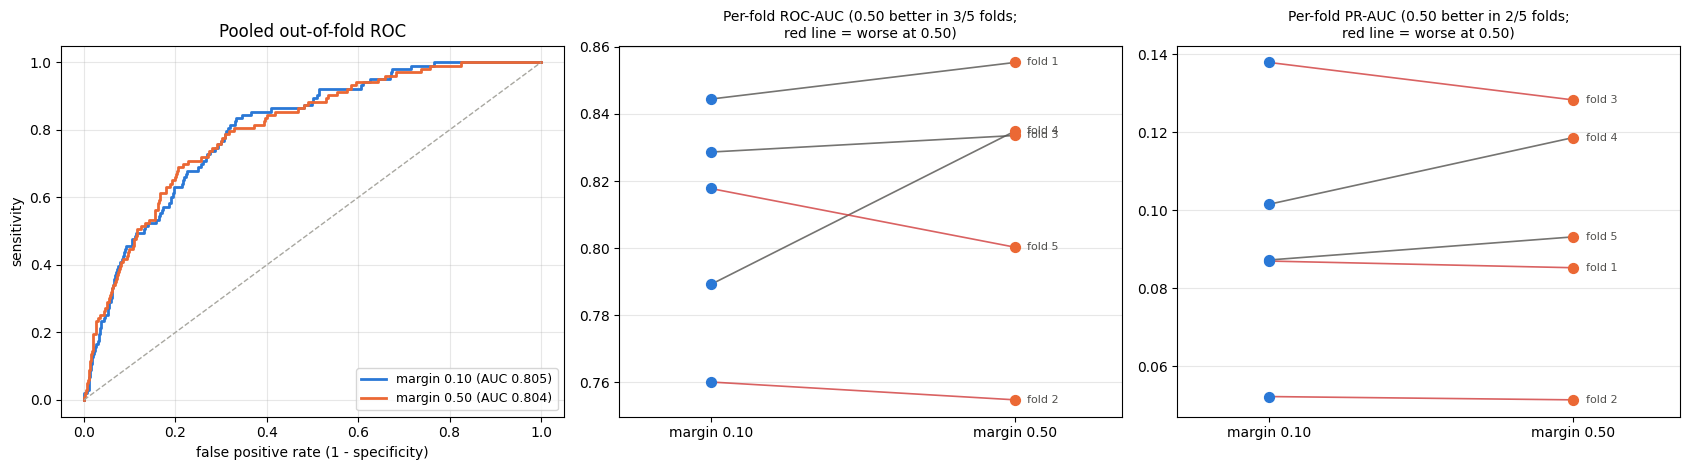

In [16]:
from sklearn.metrics import roc_curve

MARGIN_COLORS = {m_lo: '#2a78d6', m_hi: '#eb6834'}
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

# Pooled out-of-fold ROC curves
ax = axes[0]
for m, p in [(m_lo, p_lo), (m_hi, p_hi)]:
    fpr_m, tpr_m, _ = roc_curve(yt, p)
    ax.plot(fpr_m, tpr_m, color=MARGIN_COLORS[m], linewidth=2, label=f'margin {m:.2f} (AUC {roc_auc_score(yt, p):.3f})')
ax.plot([0, 1], [0, 1], linestyle='--', color='#a8a7a0', linewidth=1)
ax.set_xlabel('false positive rate (1 - specificity)')
ax.set_ylabel('sensitivity')
ax.set_title('Pooled out-of-fold ROC')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)

# Per-fold paired scores: one line per fold, going up = 0.50 better on that fold
for ax, metric in zip(axes[1:], ['ROC-AUC', 'PR-AUC']):
    for _, row in per_fold.iterrows():
        a, b = row[f'{metric} {m_lo:.2f}'], row[f'{metric} {m_hi:.2f}']
        ax.plot([0, 1], [a, b], color='#52514e' if b >= a else '#d03b3b', linewidth=1.2, alpha=0.8)
        ax.text(1.04, b, f"fold {int(row['fold'])}", fontsize=8, va='center', color='#52514e')
    for x, m in [(0, m_lo), (1, m_hi)]:
        ax.scatter(np.full(N_FOLDS, x), per_fold[f'{metric} {m:.2f}'], s=50, color=MARGIN_COLORS[m], zorder=3)
    ax.set_xticks([0, 1], [f'margin {m_lo:.2f}', f'margin {m_hi:.2f}'])
    ax.set_xlim(-0.3, 1.35)
    wins = int((per_fold[f'{metric} diff'] > 0).sum())
    ax.set_title(f'Per-fold {metric} ({m_hi:.2f} better in {wins}/{N_FOLDS} folds;\nred line = worse at {m_hi:.2f})', fontsize=10)
    ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()